In [1]:
%pylab inline

import numpy as np
import pandas as pd
import pylab as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import matplotlib
import pickle
import scipy
import time
import os
import warnings
from collections import namedtuple
from scipy.spatial.distance import pdist
warnings.filterwarnings('ignore')

sns.set_style('ticks')

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
# define data format
from collections import namedtuple
RNAseqData = namedtuple('RNAseqData', 'counts genes cells clusterIDs clusterLabels clustergroupIDs '
                                      'clusterColors clusterNames clustergroupNames cellnames mappingrates')

# create the color table for neuron clusters.
clusterColors_exc_table=np.array(['#98A14E', 
                              '#008000', '#2E8B57', '#96C390', '#6FBC1E', '#6D9269', 
                              '#90EE90', '#224700', '#228B22', '#00FF7F', '#ADD8E6',  #'#7CFC00',#  10
                              '#4666A6', '#1E90FF', '#B4BA77', '#1B655D', '#008B8B', 
                              '#00CED1', '#20B2AA', '#66CDAA', '#00FF00',])   ### greenish colors for excitatory neurons 
                              
clusterColors_inh_table = np.array(['#DDACC9', '#FF88AD', '#DD8091', '#F08E98', '#FF7290', '#FF8C97',
                              '#FFA388', '#C77963', '#7E0ACB', '#9440F3', '#9611B6', '#9900B3',
                              '#7A0099', '#AA4DB5', '#A720FF', '#AB1DFF', '#FF5FCD', '#FF4DC1',
                              '#B09FFF', '#BD3D9A', '#992E81', '#F70CF3', '#FF00FF', '#AB379C',
                              '#B3128A', '#7779BF', '#626EB8', '#FFFF00', '#FF8011', '#FF9F2C',
                              '#FFB307', '#FFBF09', '#BFAF00', '#FFB22B', '#D9C566', '#BE8652',      ### redish colors for inhibttory neurons.
                              ])

In [3]:
# load ephysio data of patchseq cells.
dataEphy = pd.read_excel('./data_ephy/Ins_patchseq_ephs.xlsx',index_col=0)
dataEphy

,ExpertCellType,predictCluster,Tau_ms,Sag_Ratio,Rm_MO,RMP_mV,Rheobase_pA,Spike_Latency_ms,Threshold_mV,AP_Amplitute,...,ISI_phaseT_ratio_CV,latency_slope,FR_slope,firstISI_slope,ISI_adpIdx_slope,ampAdpIdx_slope,firstSpikePhaseArea,firstSpikePhasePerimeter,spikePhaseAreaRatio,spikePhasePerimeterRatio
Cell_ID,,,,,,,,,,,,,,,,,,,,,
s170,NaN,18,43.492,1.067,115.514,-65.323,140,160.66,-39.984,83.352,...,0.452,0.167,0.012,-0.21,2.263,0.1125,8906.444,568.273,3.535,1.794
s173,VEN_Long,16,33.006,1.180,88.803,-65.951,40,211.50,-55.373,98.921,...,0.514,0.397,0.054,-0.474,-6.09,-0.7318,13018.269,684.670,4.735,2.021
s174,VEN_Long,16,81.344,1.338,213.686,-59.412,60,108.58,-40.287,83.135,...,0.646,0.431,0.017,-0.164,3.938,-0.7154,8373.448,543.616,4.057,1.855
s175,PC_L5,18,55.866,1.080,159.960,-64.555,100,230.20,-38.491,79.421,...,0.144,0.187,0.031,-0.599,2.695,-0.3943,5758.154,466.527,4.386,1.929
s177,NaN,14,26.871,1.064,148.930,-55.866,180,144.06,-16.784,90.807,...,0.514,0.133,0.051,-0.346,12.025,-13.3033,10269.045,611.233,5.556,2.227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
n191,PC_L5,14,23.672,1.070,161.129,-57.289,80,74.92,-35.989,83.542,...,0.28,0.579,0.081,-0.946,1.574,-0.1229,11880.731,660.252,3.821,1.901
n193,L23_PC,15,23.377,1.115,256.807,-69.698,20,249.40,-50.287,90.344,...,0.334,0.595,0.167,-1.111,3.623,-0.9982,13609.246,701.057,7.839,2.831
n197,L23_PC,15,26.777,1.097,203.829,-66.974,80,110.20,-37.927,92.014,...,0.311,0.415,0.083,-1.061,1.119,-1.323,14299.362,724.031,9.8,3.123


In [4]:
dataEphy=dataEphy.dropna(axis=0)

In [5]:
# loading patched cell data
patchSeqData=pickle.load(open('../patchSeqMappingTo10X//data/processedData/insPatchDataNew251010.pickle', 'rb')) 
# patchSeqData=pickle.load(open('./data/processedData/insPatchData.pickle', 'rb')) 
counts_patchSeq = patchSeqData.counts
genes_patchSeq = patchSeqData.genes.astype('str')
patchCellNames = patchSeqData.cellnames
patchCellTypeIDs = patchSeqData.clustergroupIDs
patchCellTypes = patchSeqData.clustergroupNames
patchCellSubtypeIDs= patchSeqData.clusterIDs
patchCellSubtypes= patchSeqData.clusterNames
mappingRates= patchSeqData.mappingrates

In [6]:
# load the predicted cluster IDs of patchSeq cells.
predictClusterIDs = pd.read_csv('../patchSeqMappingTo10X/data/mappingRes/results_Ext_240415.csv',index_col=0)
# featureMerged = pd.concat([somaDepth_norm_good,predictClusterIDs],axis=1,join='inner',ignore_index=False)
# featureMerged

# Load the excitatory neurons (10X)

In [7]:
# load the umap mapping positions of patch-seq cells
mappingUmap_Ext = pd.read_csv('../patchSeqMappingTo10X//data/mappingRes/df_pos_umap_Ext_240415.csv', index_col=0)
# load the scanpy data of Ext neurons.
ad_Ext = sc.read('../10X/data_h5/Ext.h5ad')
ad_Ext

AnnData object with n_obs × n_vars = 21733 × 19944
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cluster_labels', 'sampleLayers', 'projectionCellType', 'Sex'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sex_colors', 'batch_colors', 'cluster_labels_colors', 'cluster_names', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'projectionCellType_colors', 'rank_genes_groups', 'sampleLayers_colors', 'tsne', 'umap'
    obsm: 'X_harmonypca', 'X_pca', 'X_tsne', 'X_umap', 'X_umapharmony', 'X_umapraw'
    varm: 'PCs'
    layers: 'RawCounts'
    obsp: 'connectivities', 'distances'

In [8]:
# get the umap positions of 10X data.
Z0_umap = ad_Ext.obsm['X_umap']
# assign the colors to Ext neuron subtypes.
clusterColors_Ext = clusterColors_exc_table[ad_Ext.obs['leiden'].astype('int')]

In [9]:
tem = pd.read_csv('../patchSeqMappingTo10X/data/mappingRes/HVG_10XExt.csv',index_col=0)
HVG_ext = list(tem['0'])

gg = sorted(list(set(genes_patchSeq) & set(HVG_ext)))
idx_HVG_new = [np.where(genes_patchSeq==g)[0][0] for g in gg]
HVG_new = genes_patchSeq[idx_HVG_new]
counts_patchSeq = counts_patchSeq[:, idx_HVG_new]         ### IMPORTANT: If first time ran the routine, this line need to be un-commented.

In [10]:
dataEphy

,ExpertCellType,predictCluster,Tau_ms,Sag_Ratio,Rm_MO,RMP_mV,Rheobase_pA,Spike_Latency_ms,Threshold_mV,AP_Amplitute,...,ISI_phaseT_ratio_CV,latency_slope,FR_slope,firstISI_slope,ISI_adpIdx_slope,ampAdpIdx_slope,firstSpikePhaseArea,firstSpikePhasePerimeter,spikePhaseAreaRatio,spikePhasePerimeterRatio
Cell_ID,,,,,,,,,,,,,,,,,,,,,
s175,PC_L5,18,55.866,1.080,159.960,-64.555,100,230.20,-38.491,79.421,...,0.144,0.187,0.031,-0.599,2.695,-0.3943,5758.154,466.527,4.386,1.929
s218,PC_L5,18,46.535,1.056,119.006,-60.193,80,281.42,-36.685,96.641,...,0.359,0.111,0.029,-0.917,0.648,1.0195,12850.227,685.870,3.331,1.744
s222,PC_L5,6,23.008,1.065,136.080,-64.968,80,176.70,-34.593,92.725,...,0.227,0.195,0.049,-1.538,1.368,-2.7611,11917.338,658.679,2.752,1.587
s227,PC_L23,14,40.442,1.077,116.168,-63.662,80,267.24,-41.124,92.454,...,0.231,0.162,0.031,-1.092,0.952,0.0317,10643.828,625.243,2.848,1.618
s209,INTER_L5,24,24.249,1.285,301.066,-54.818,20,18.62,-50.231,88.380,...,0.654,NaN,NaN,NaN,NaN,NaN,8953.235,554.467,2.133,1.389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
n190,PC_L5,16,11.800,1.364,70.139,-70.932,140,71.76,-54.121,96.390,...,0.539,0.263,0.081,-0.14,-31.466,-1.9562,14688.610,699.920,4.528,2.23
n191,PC_L5,14,23.672,1.070,161.129,-57.289,80,74.92,-35.989,83.542,...,0.28,0.579,0.081,-0.946,1.574,-0.1229,11880.731,660.252,3.821,1.901
n193,L23_PC,15,23.377,1.115,256.807,-69.698,20,249.40,-50.287,90.344,...,0.334,0.595,0.167,-1.111,3.623,-0.9982,13609.246,701.057,7.839,2.831


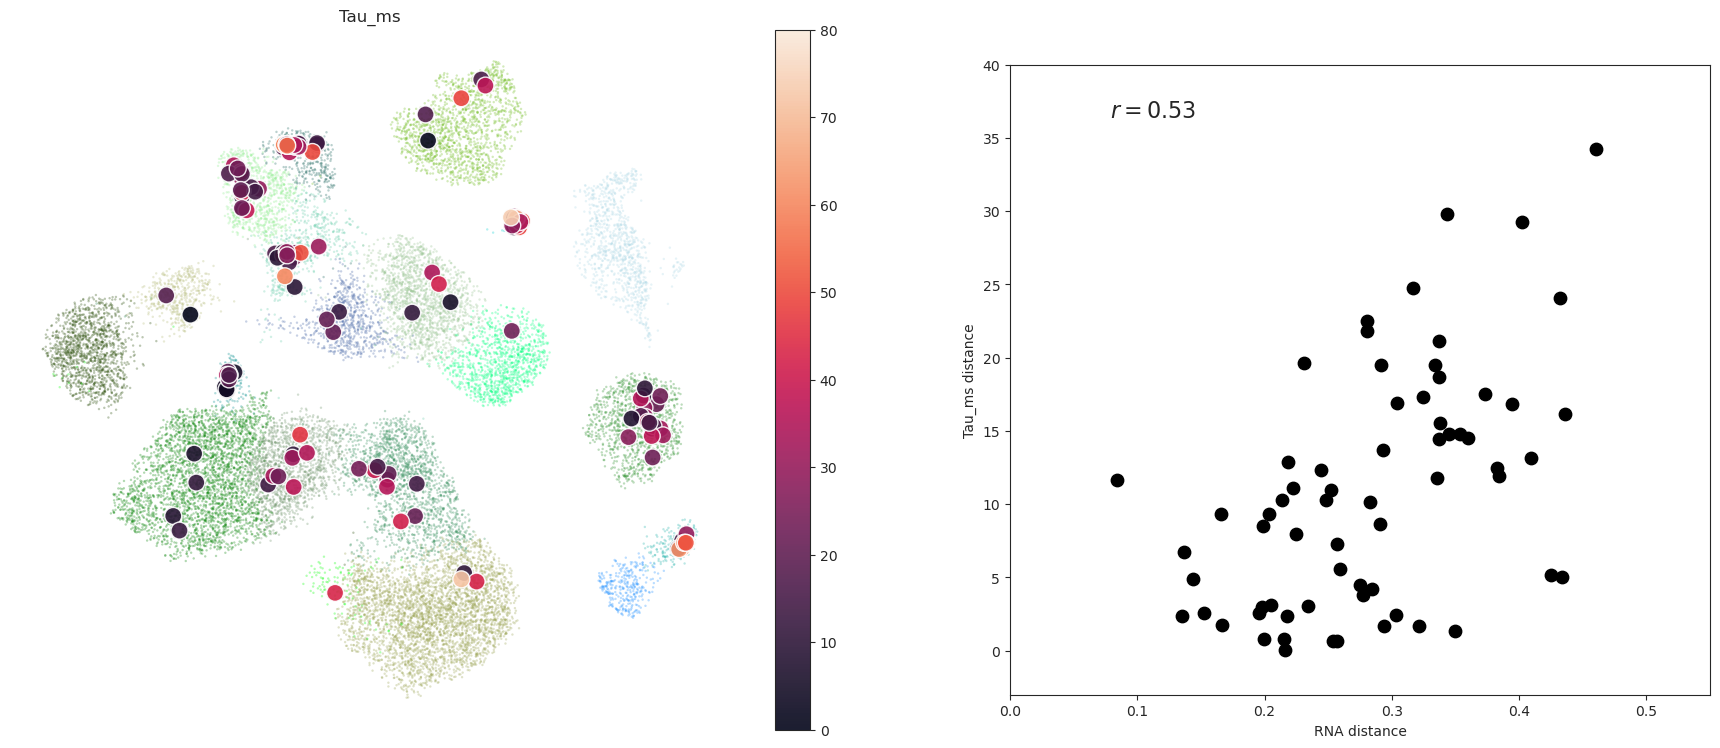

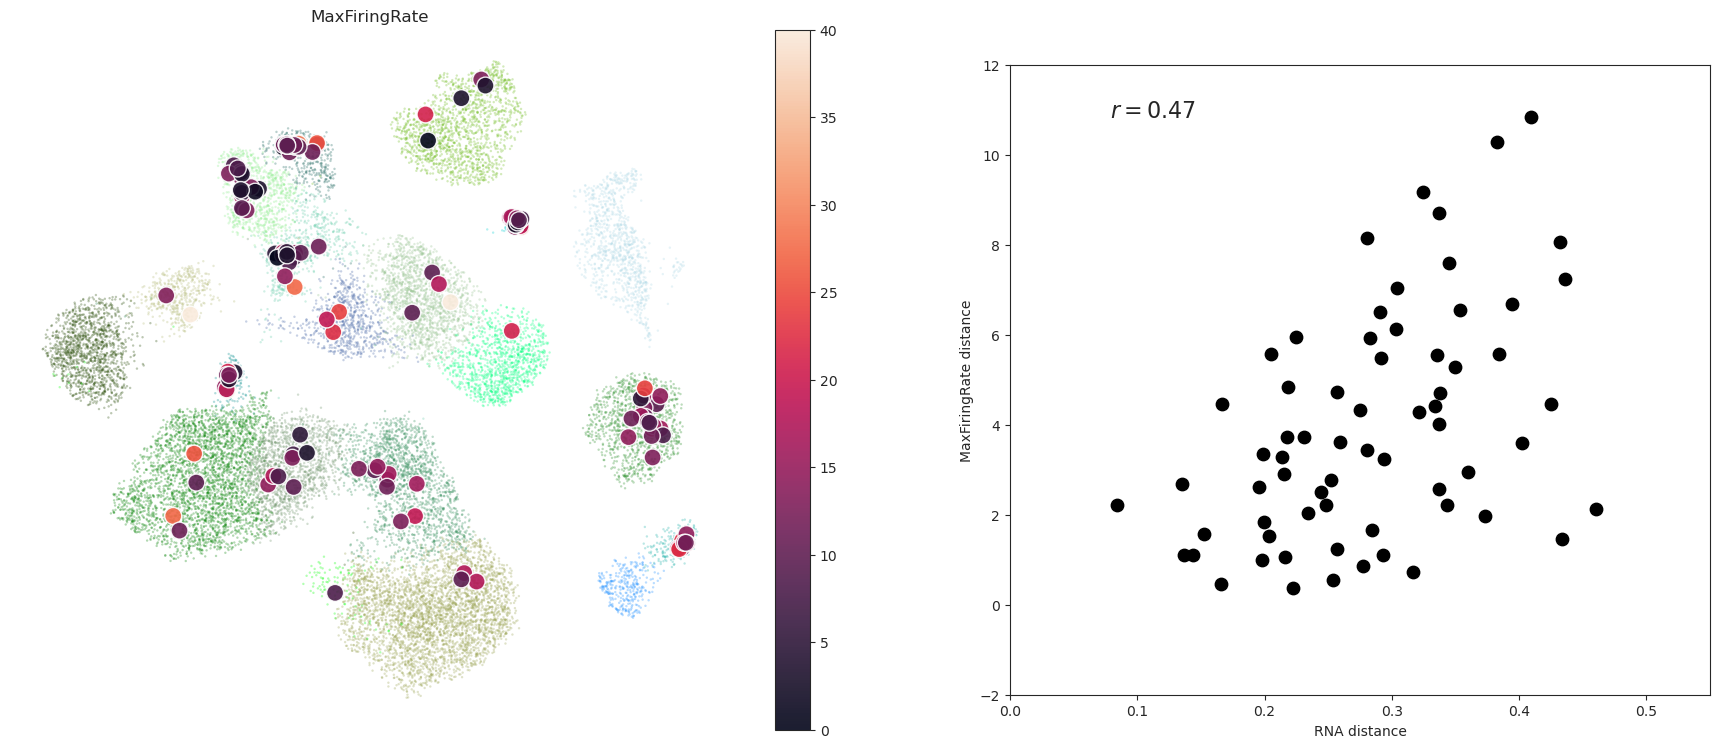

In [11]:
## plot the typical ephy feature: Tau_ms.

exampleFeat = ['Tau_ms','MaxFiringRate']
dotsize = 150
# dotsize=25

for i, feat in enumerate(exampleFeat):
    # get the morph feature values.
    featValues = dataEphy[feat]
    
    # remove the cells with this feature is NaN.
    featValues = featValues.replace(r'.*NaN.*', pd.NA, regex=True)
    featValues=featValues.dropna(axis=0)

    goodCell_ind = intersect1d(featValues.index,mappingUmap_Ext.index)
    featValues_good = featValues.loc[ goodCell_ind]
    mappingUmap_Ext_good=mappingUmap_Ext.loc[ goodCell_ind,:]
    
    # jitter for the overlapped dots (dots mapping to the cluster FEZF2 DSG2) 
    overlapDots = (mappingUmap_Ext['UMAP1']>8.5) & (mappingUmap_Ext['UMAP1']<8.8) & (mappingUmap_Ext['UMAP2']>14) & (mappingUmap_Ext['UMAP2']<15)
    mappingUmap_overlapped = mappingUmap_Ext_good.loc[overlapDots,:]
    mappingUmap_nonOverlapped = mappingUmap_Ext_good.loc[~overlapDots,:]
    n_overlopDots = mappingUmap_overlapped.shape[0]
    
    # plot the mapping figures.
    fig = plt.figure(figsize=(20,7))
    # fig = plt.figure(figsize=(10,3.5))
    ax1 = plt.axes([0.05,0,9/20,1])
    # plot 10X data
    plt.sca(ax1)
    plt.scatter(Z0_umap[:,0], Z0_umap[:,1], s=3, alpha=0.3,
                c = clusterColors_Ext, edgecolor='none',
                rasterized=True )
    # plot the cells with good ephy feature values.
    plt.scatter(mappingUmap_nonOverlapped['UMAP1'], mappingUmap_nonOverlapped['UMAP2'], s=dotsize, alpha=0.9,
                c = np.array(featValues_good[~overlapDots]), edgecolor='w', rasterized=True)
    plt.scatter(mappingUmap_overlapped['UMAP1']+0.7*np.random.rand(n_overlopDots), mappingUmap_overlapped['UMAP2']+0.7*np.random.rand(n_overlopDots), s=dotsize, alpha=0.9,
                c = np.array(featValues_good[overlapDots]), edgecolor='w', rasterized=True)
    
    # plt.scatter(mappingUmap_Ext_good['umap1'], mappingUmap_Ext_good['umap2'], s=dotsize, alpha=0.9,
    #             c = np.array(featValues_good), edgecolor='w', rasterized=True)
    colorbar()
    # set figure properties
    if feat=='Tau_ms':
        plt.clim(0,80)
    else:
        plt.clim(0,40)
    plt.xticks([])
    plt.yticks([])
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.title(feat)


    ax2 = plt.axes([11/20,0.05, 7/20,0.9])
    
    featureMerged = pd.concat([featValues_good,predictClusterIDs],axis=1,join='inner',ignore_index=False)
    # featureMerged
    patchDataMtx = pd.DataFrame(counts_patchSeq,index=patchCellNames,columns=HVG_new)
    patchDataMtxMerged = pd.concat([featureMerged,patchDataMtx],axis=1,join='inner',ignore_index=False)

    clusters = np.array([ 0, 1,  2, 4, 5, 6, 8, 14, 15, 16, 17, 18 ]) # only includes the cluster with >5 neurons mapped.
    meanFeatValues = np.ones(len(clusters))*np.nan
    meanCounts = np.ones([len(clusters), len(HVG_new)])*np.nan

    for j, cluster in enumerate(clusters):
        meanFeatValues[j] = np.mean(featureMerged.loc[featureMerged['predictClustersIDs']==cluster,feat])
        # meanCounts[j] = np.mean( np.log1p(patchDataMtxMerged.loc[patchDataMtxMerged['predictClustersIDs']==cluster,'ACSL3':]),axis=0 )  #'ACSL3'
        meanCounts[j] = np.log1p( np.mean(patchDataMtxMerged.loc[patchDataMtxMerged['predictClustersIDs']==cluster,'ACSL3':],axis=0) )

    Dist_ephyFeat = pdist(meanFeatValues[:,np.newaxis])
    Dist_counts = pdist(meanCounts,metric='correlation')
    # remove the NaNs.
    Dist_ephyFeat = Dist_ephyFeat[~isnan(Dist_ephyFeat)]
    Dist_counts = Dist_counts[~isnan(Dist_ephyFeat)]

    plt.scatter(Dist_counts,Dist_ephyFeat,color='k',s=80)
    plt.xlim([0,0.55])
    if feat=='Tau_ms':
        plt.ylim([-3,40])
    else:
        plt.ylim([-2,12.01])
    plt.xlabel('RNA distance')
    plt.ylabel( feat + ' distance')

    corrco=corrcoef(Dist_counts,Dist_ephyFeat)
    fig.text(12/20, .9, '$r={:.2f}$'.format(corrco[1,0]), fontsize=16, va='top')

    # saveName = './figures/singleCellMapping/'+feat+'.pdf'
    # plt.savefig(saveName,dpi=600)

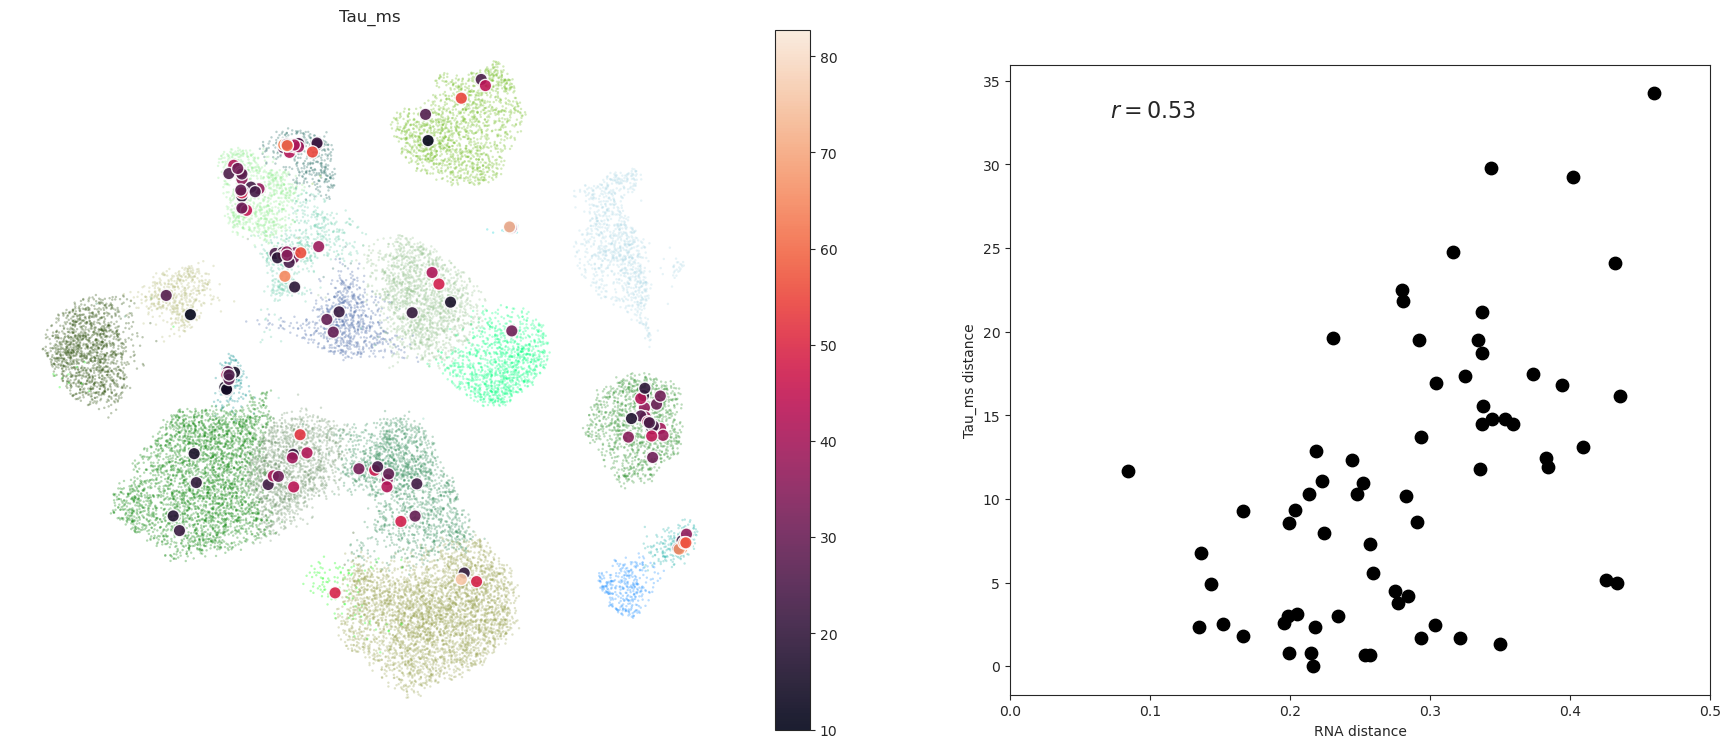

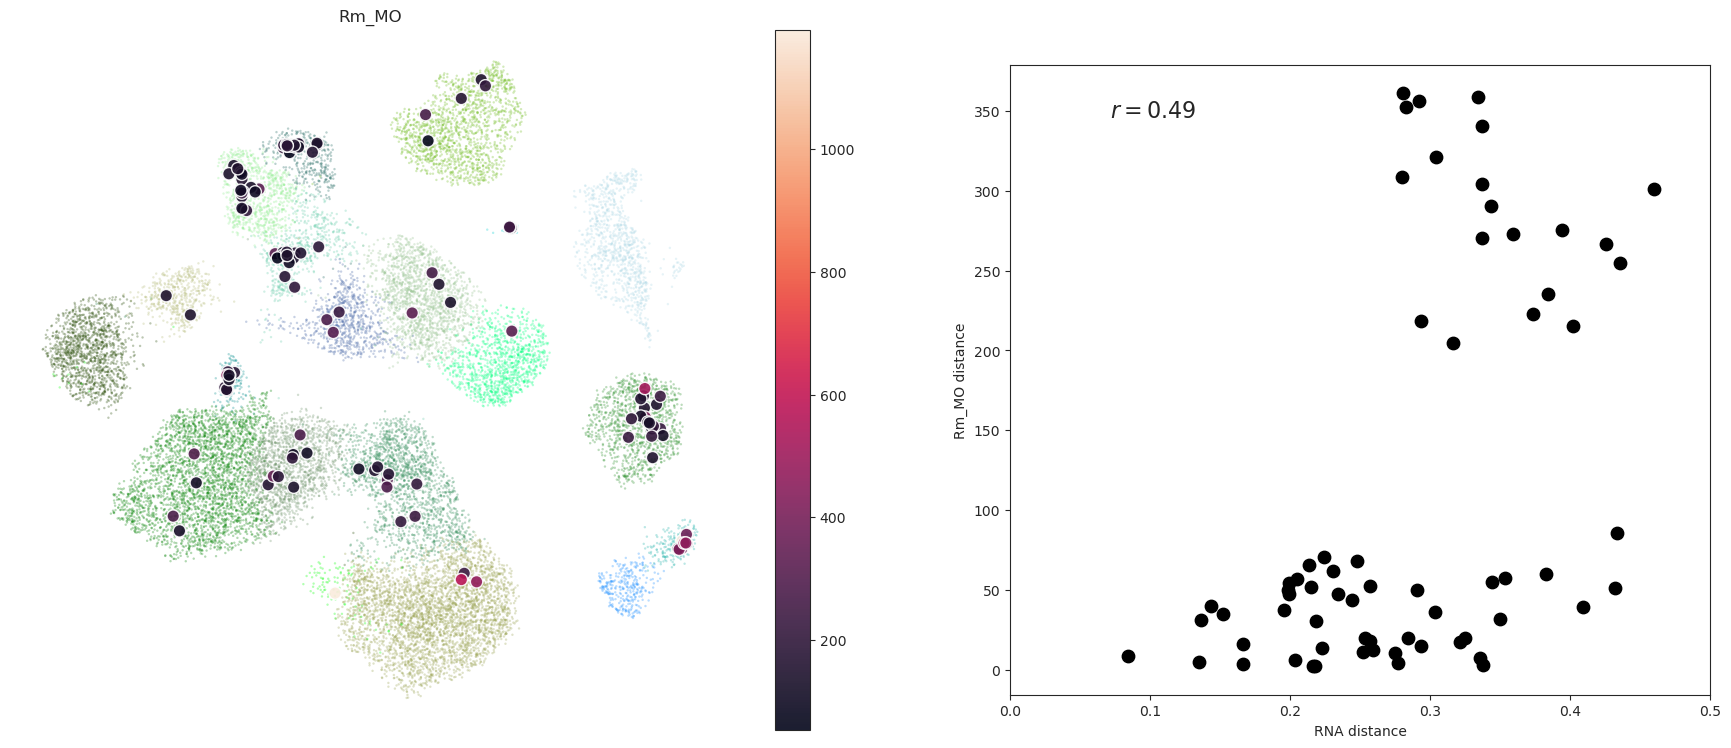

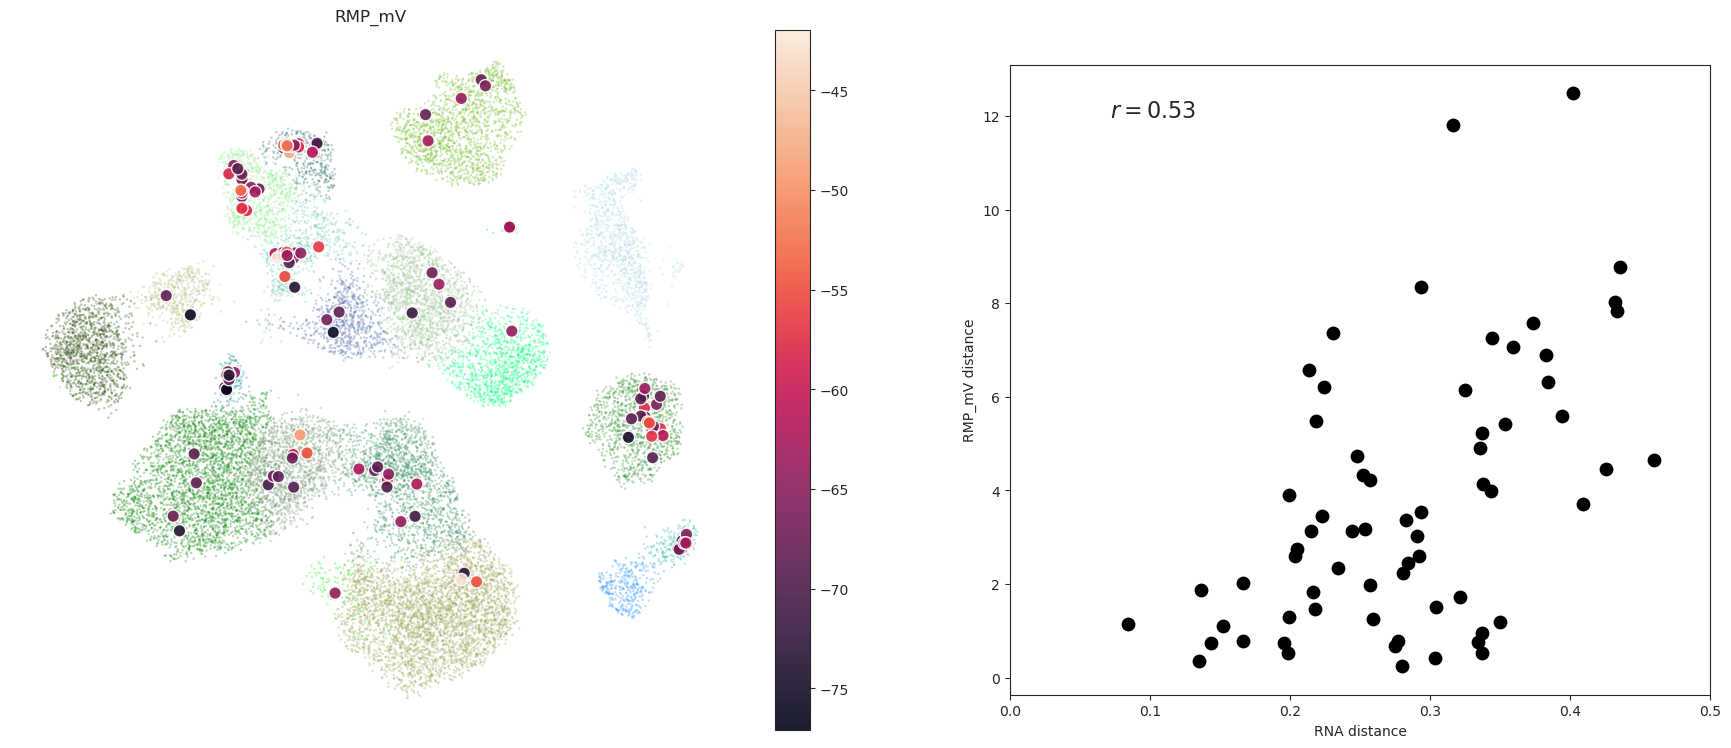

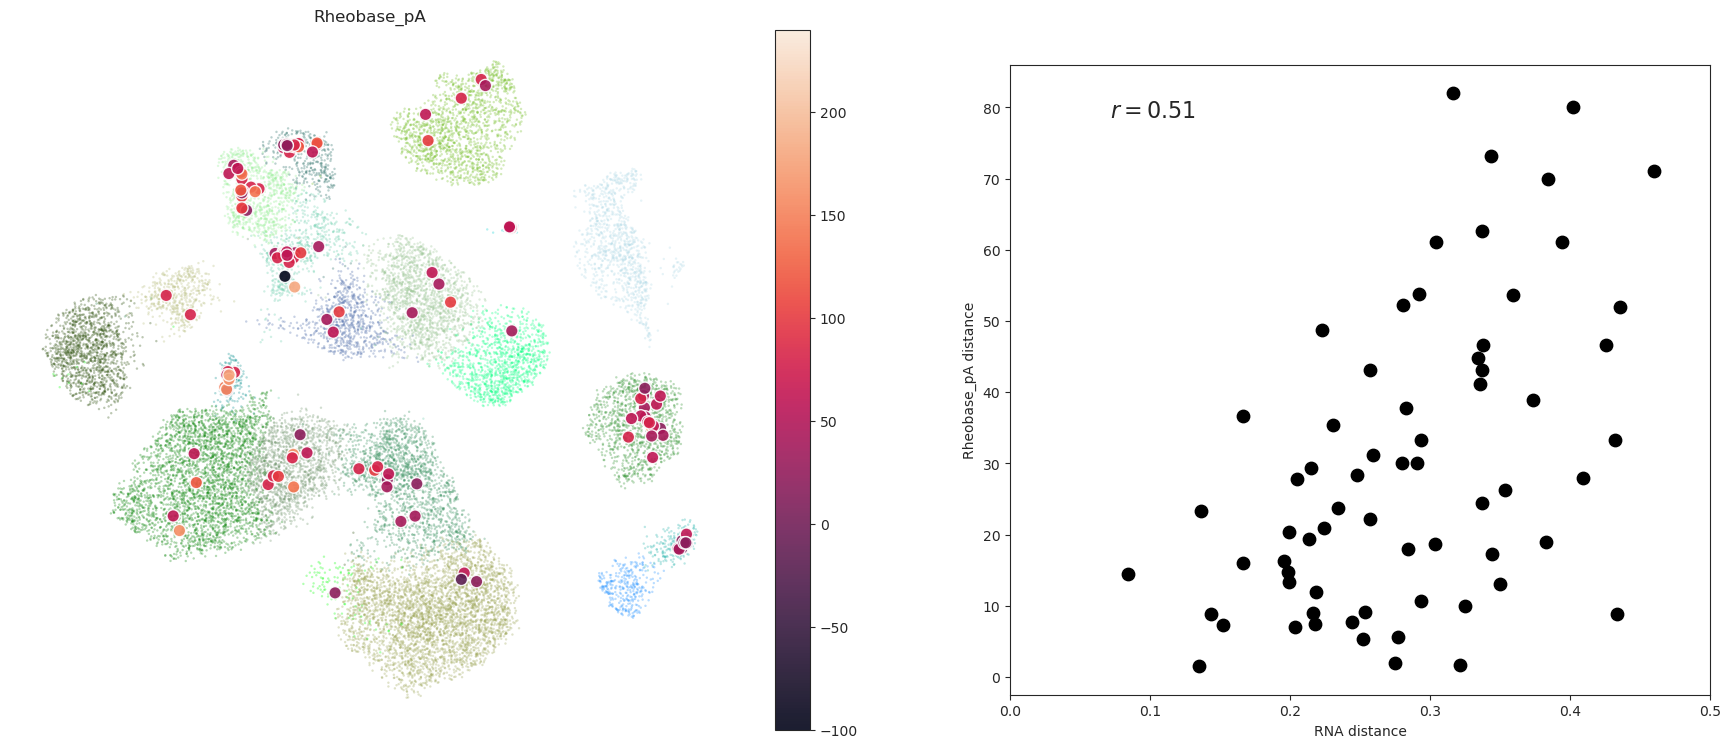

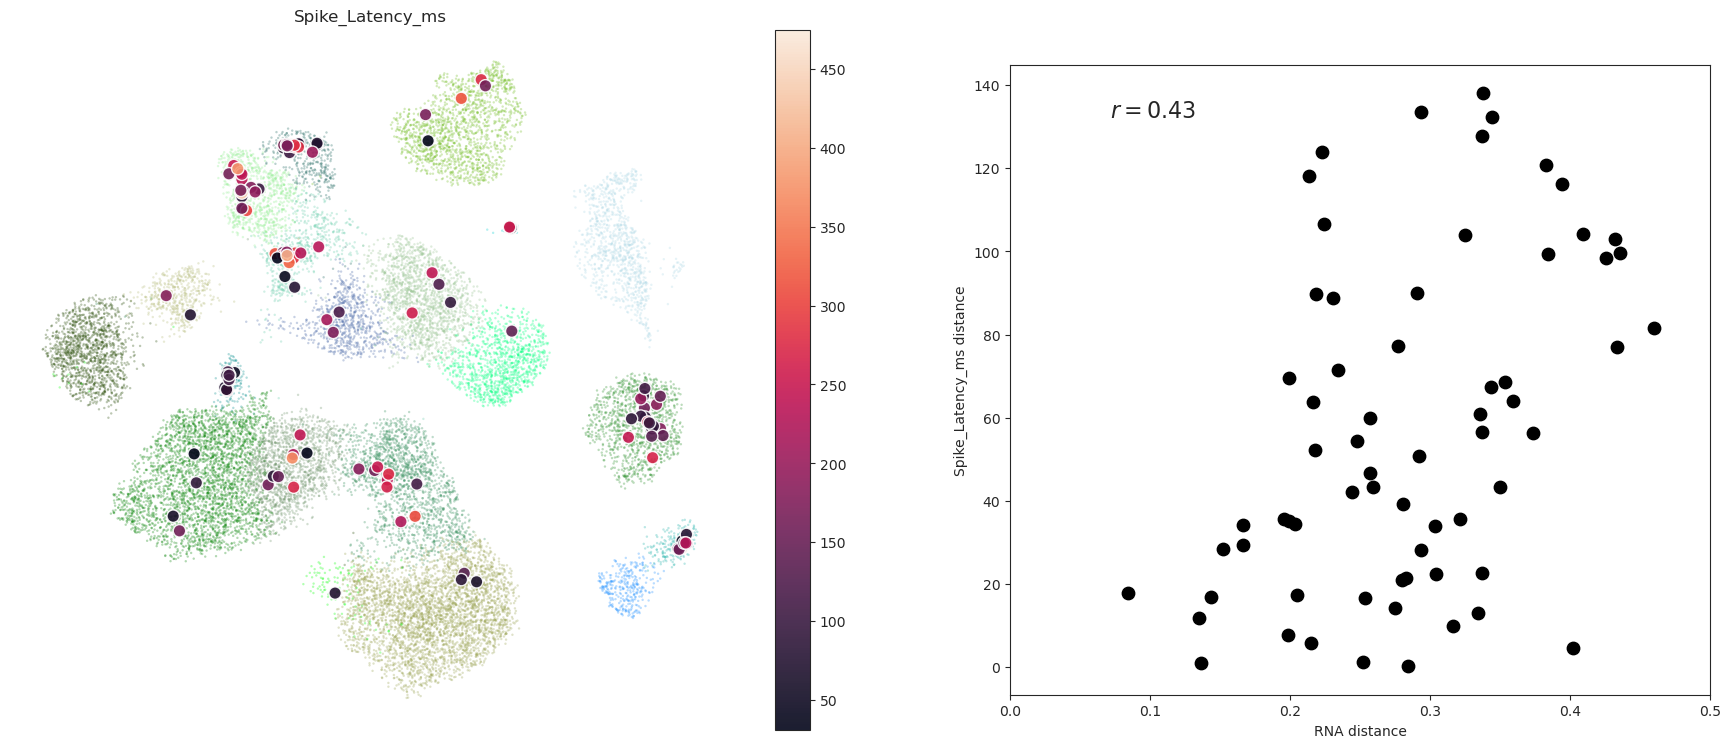

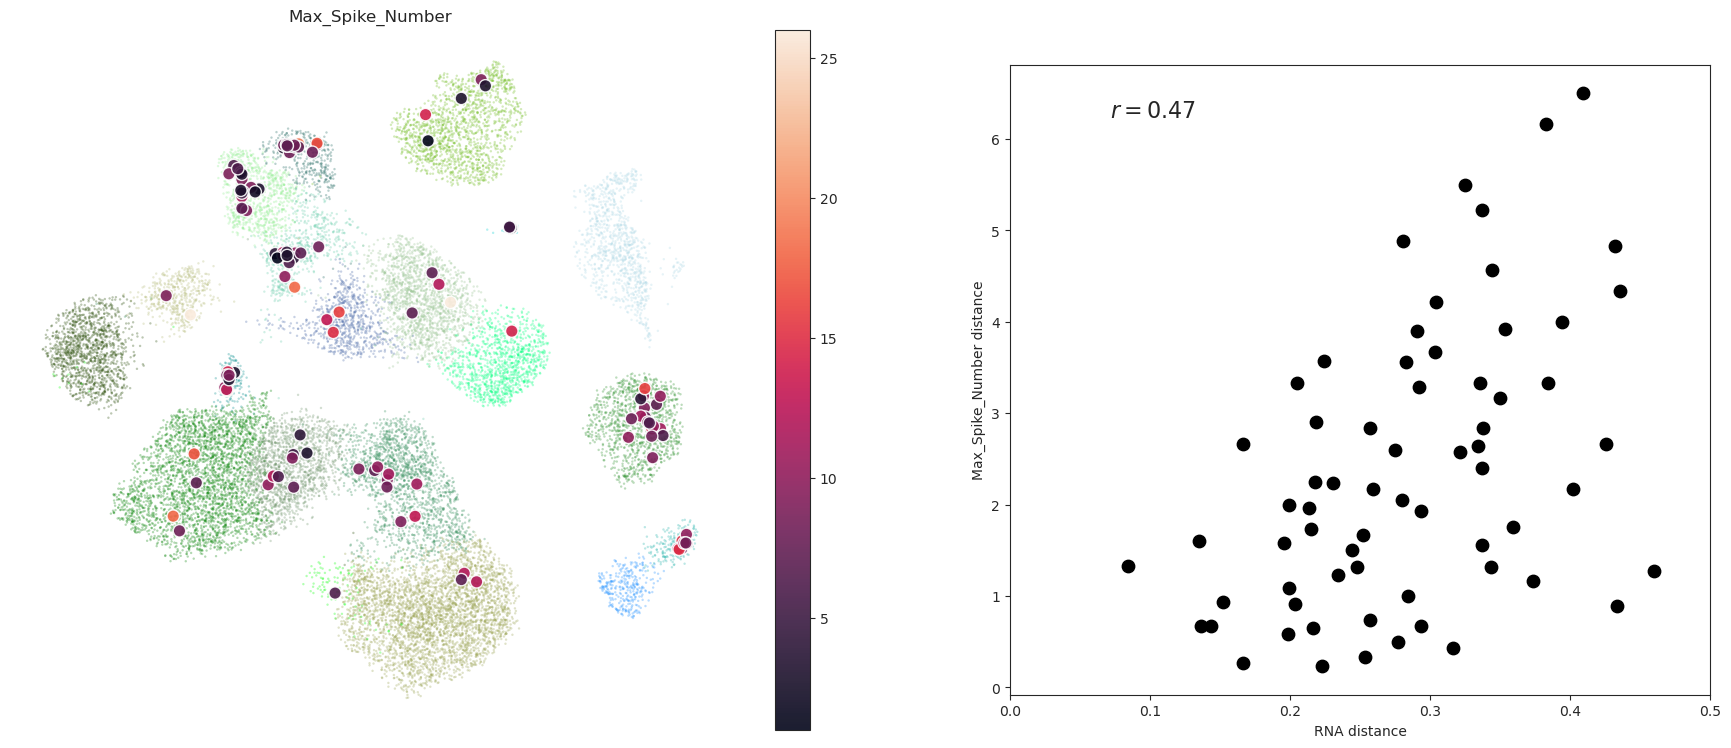

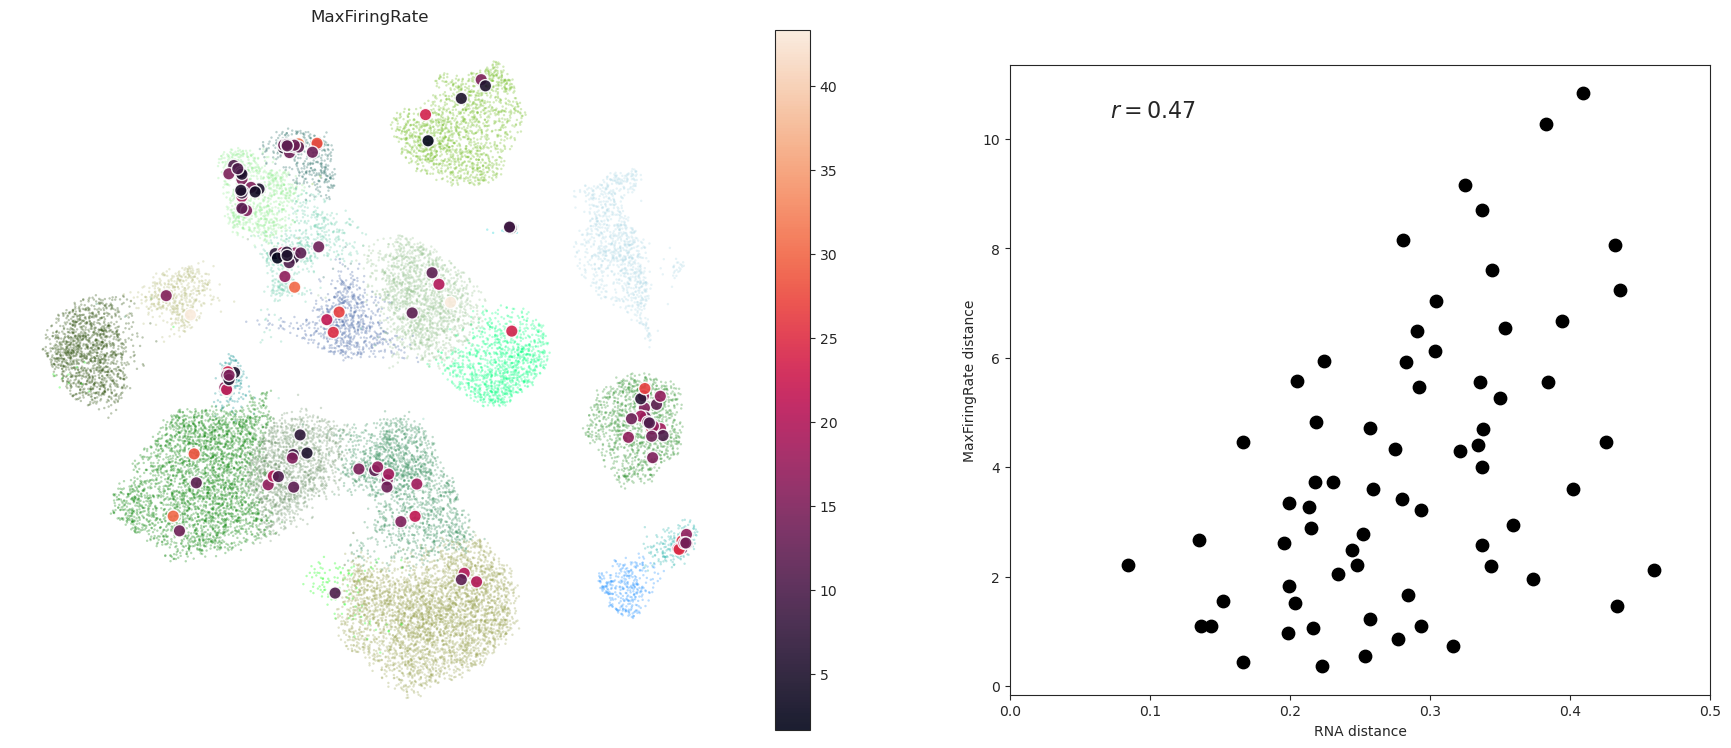

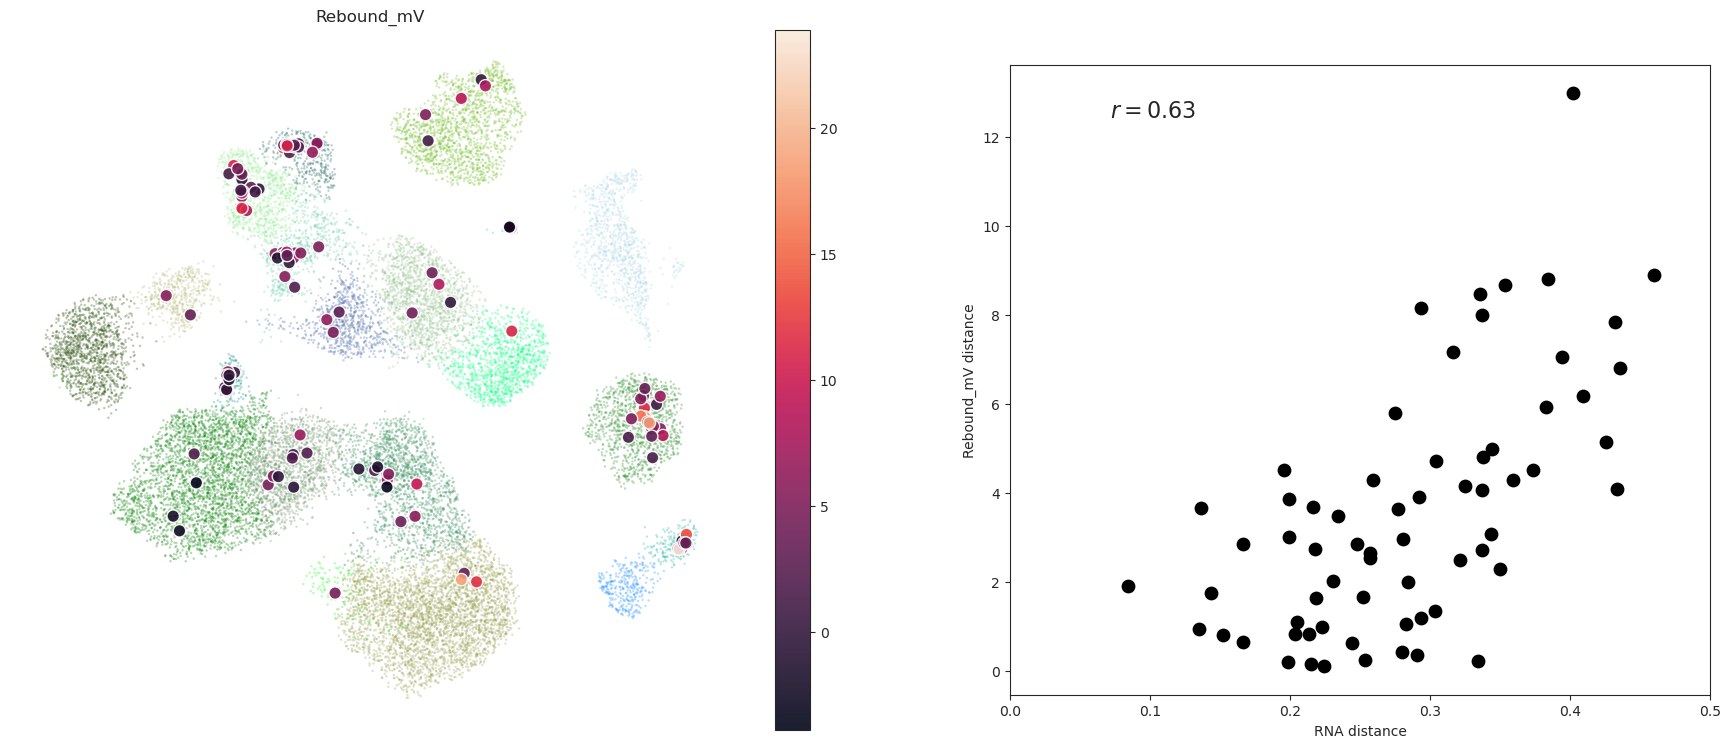

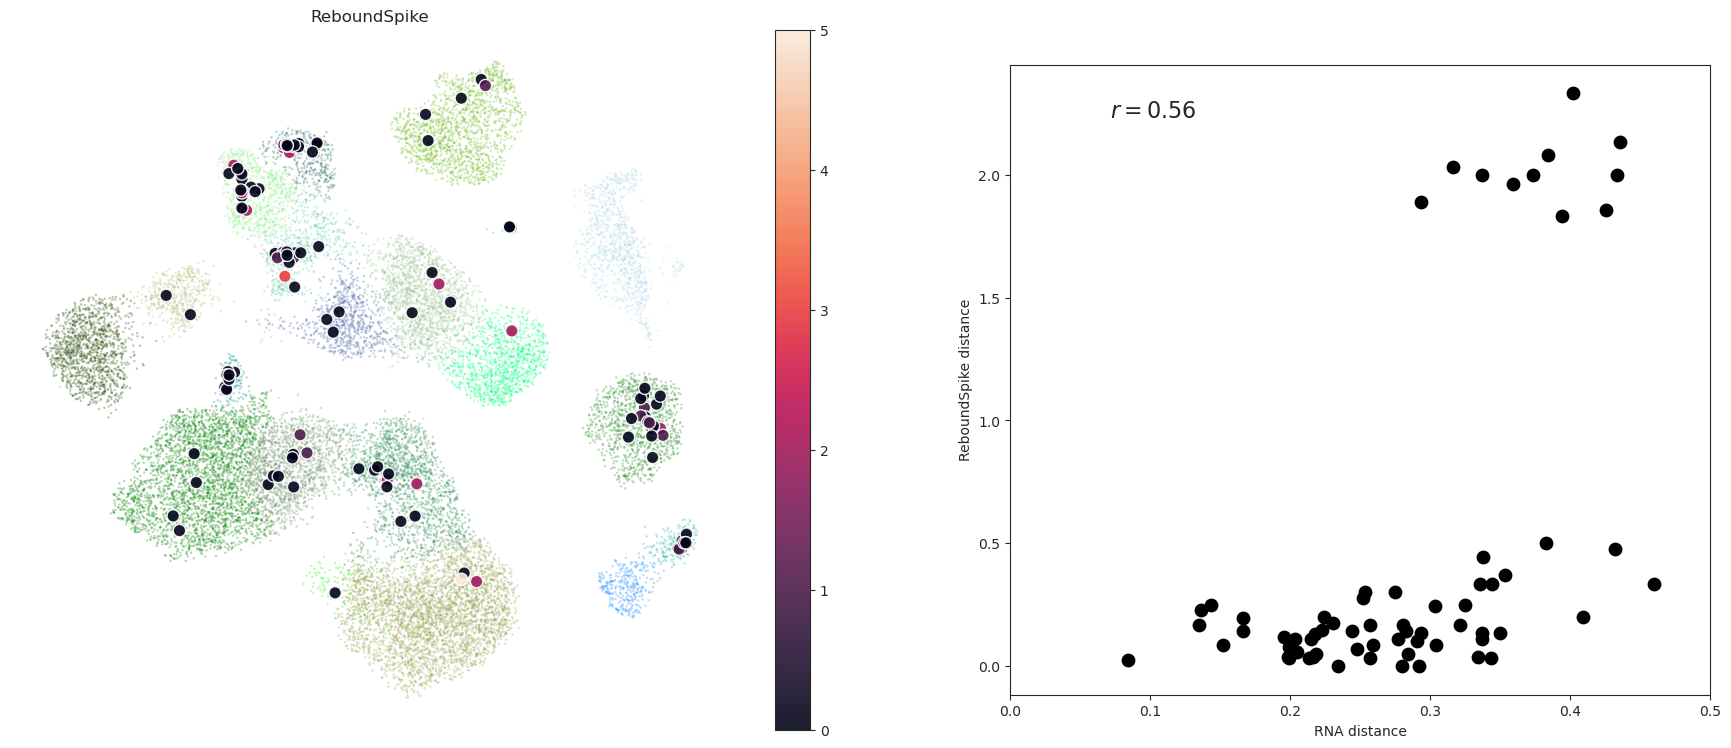

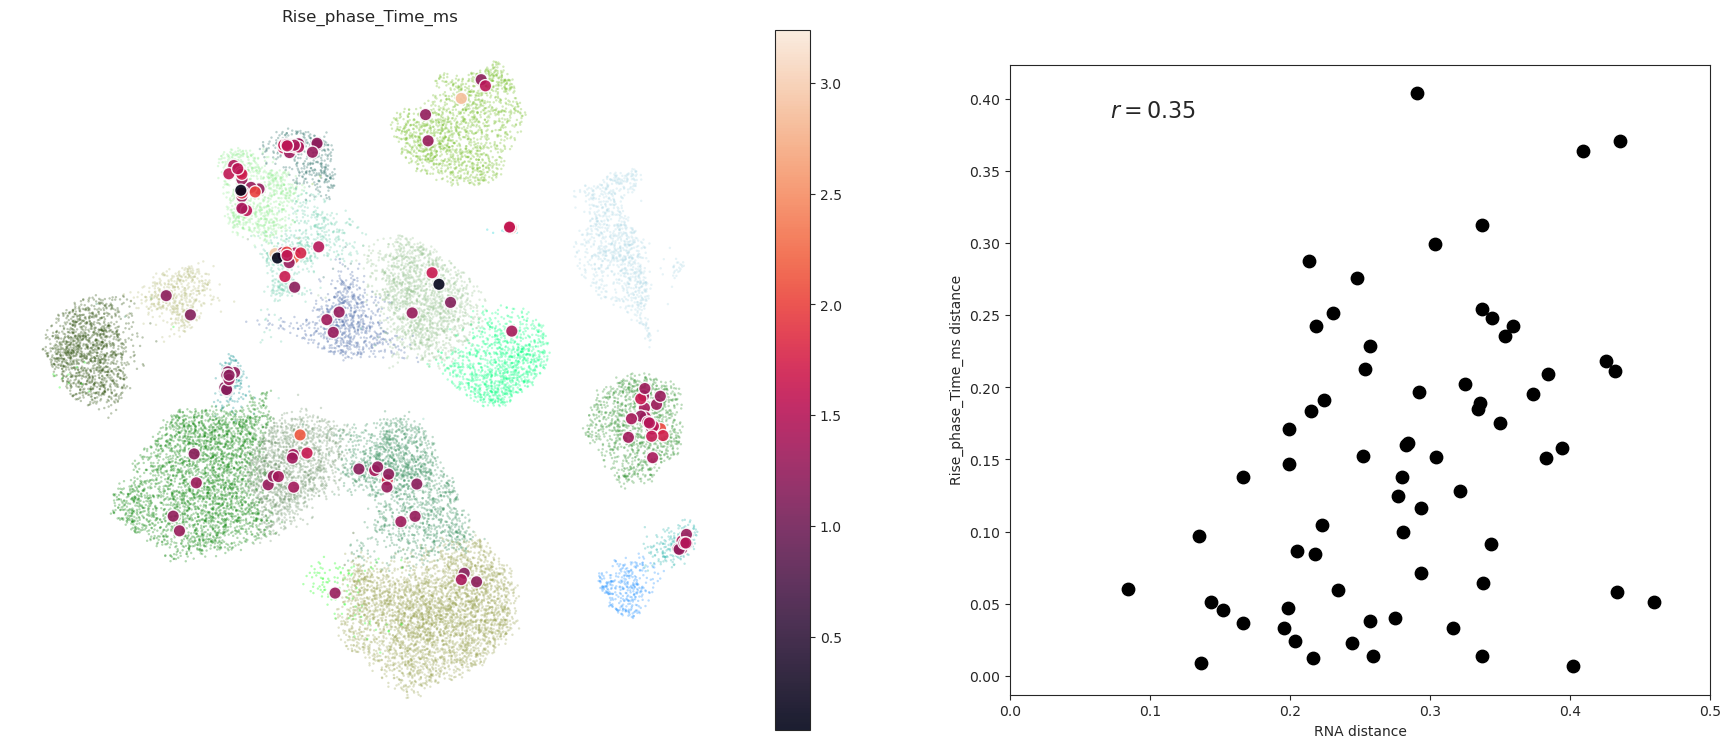

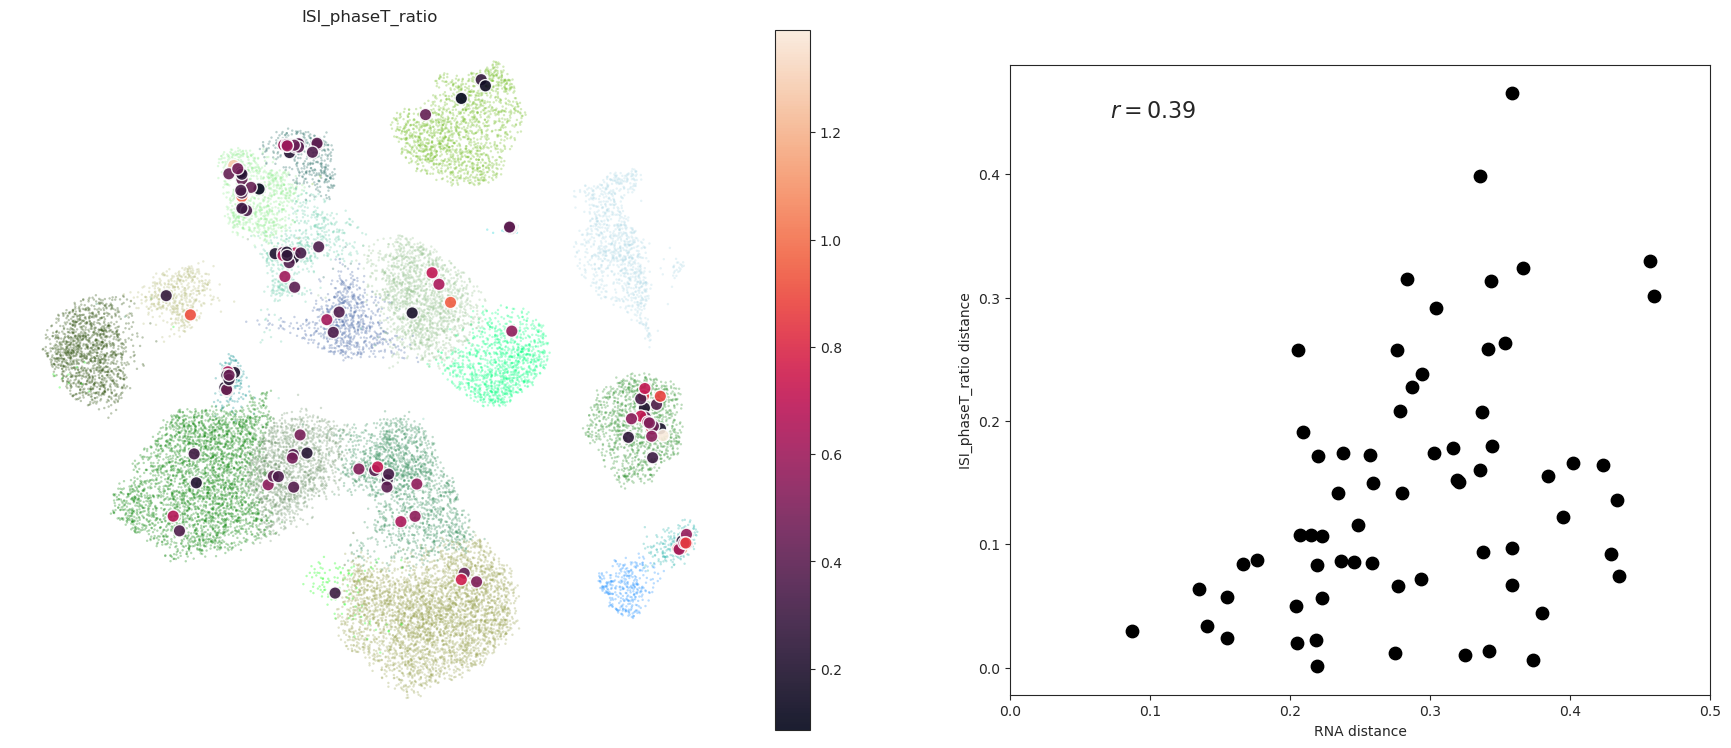

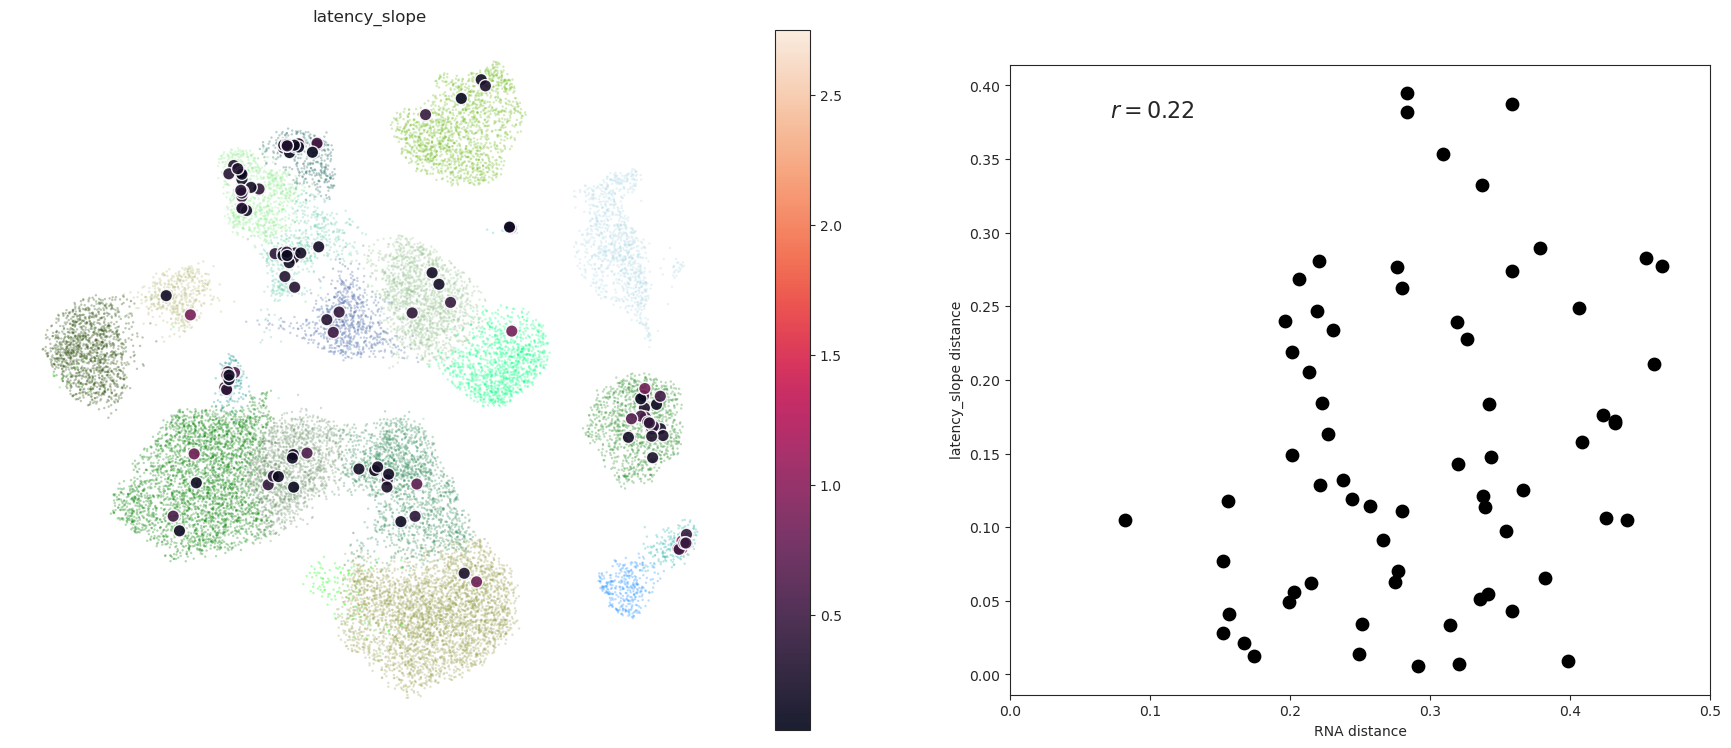

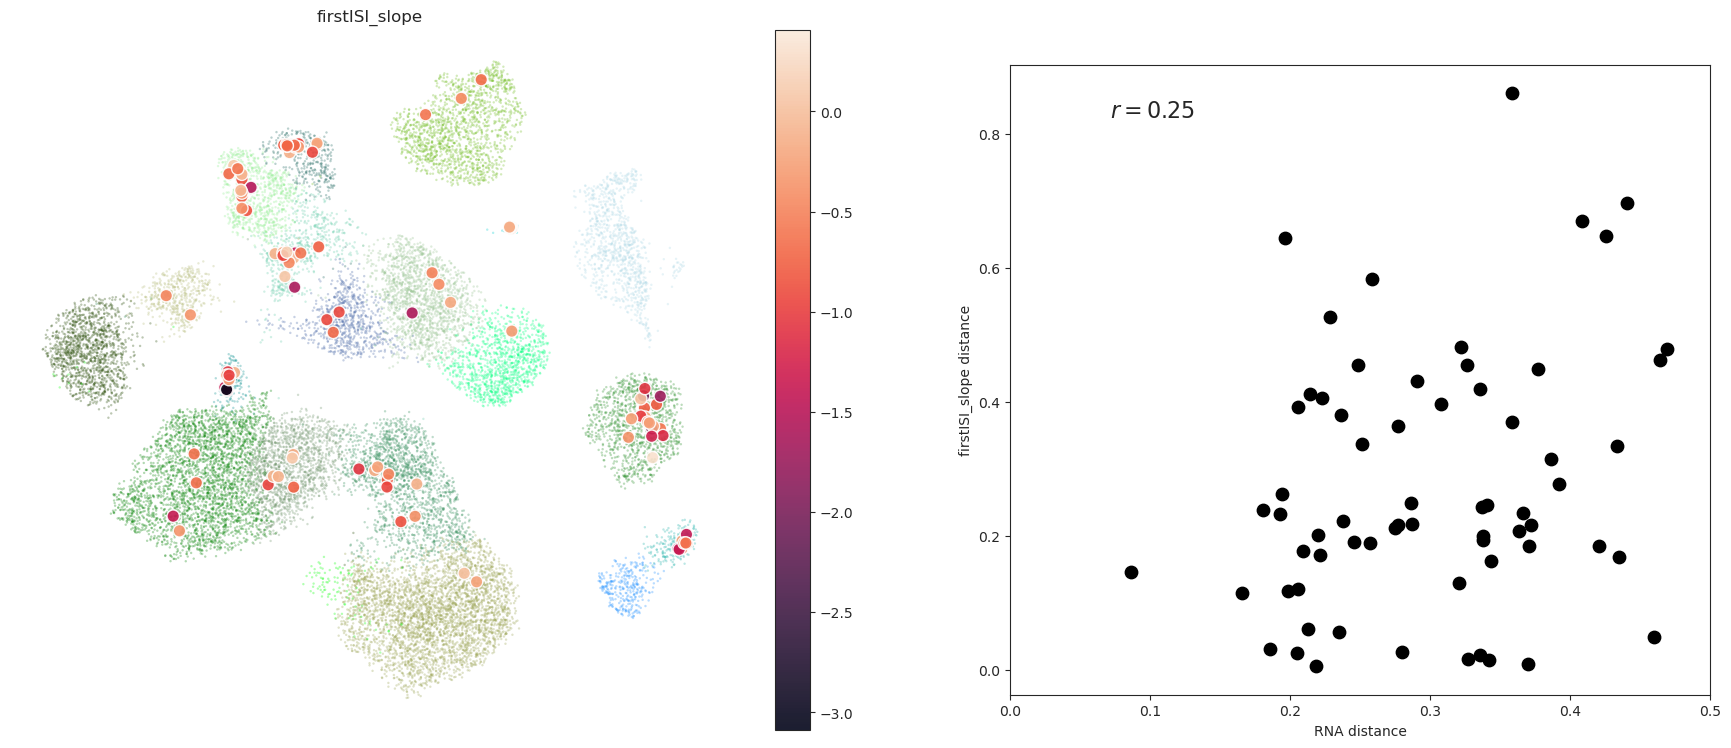

In [15]:
# plot all ehy features mapping 2 10X RNAseq data.

ephyFeatureNames = dataEphy.columns[2:]

highCorrFeatures = ['Tau_ms', 'Rm_MO', 'RMP_mV', 'Rheobase_pA', 'Spike_Latency_ms',  
       'Max_Spike_Number', 'MaxFiringRate', 'Rebound_mV', 'ReboundSpike',
       'Rise_phase_Time_ms', 'ISI_phaseT_ratio', 'latency_slope', 
       'firstISI_slope', ];

for i, feat in enumerate(highCorrFeatures):

    # get the morph feature values.
    featValues = dataEphy[feat]
    
    # remove the cells with this feature is NaN.
    featValues = featValues.replace(r'.*NaN.*', pd.NA, regex=True)
    featValues=featValues.dropna(axis=0)
    
    goodCell_ind = intersect1d(featValues.index,mappingUmap_Ext.index)
    featValues_good = featValues.loc[ goodCell_ind]
    mappingUmap_Ext_good=mappingUmap_Ext.loc[ goodCell_ind,:]

    # plot the mapping figures.
    fig = plt.figure(figsize=(20,7))
    ax1 = plt.axes([0.05,0,9/20,1])
    # plot 10X data
    plt.sca(ax1)
    plt.scatter(Z0_umap[:,0], Z0_umap[:,1], s=3, alpha=0.3,
                c = clusterColors_Ext, edgecolor='none',
                rasterized=True )
    # plot the cells with good ephy feature values.
    plt.scatter(mappingUmap_Ext_good['UMAP1'], mappingUmap_Ext_good['UMAP2'], s=80, alpha=0.9,
                c = np.array(featValues_good), edgecolor='w', rasterized=True)
    colorbar()
    # set figure properties
    plt.xticks([])
    plt.yticks([])
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.title(feat)


    ax2 = plt.axes([11/20,0.05, 7/20,0.9])
    featureMerged = pd.concat([featValues_good,predictClusterIDs],axis=1,join='inner',ignore_index=False)
    # featureMerged
    patchDataMtx = pd.DataFrame(counts_patchSeq,index=patchCellNames,columns=HVG_new)
    patchDataMtxMerged = pd.concat([featureMerged,patchDataMtx],axis=1,join='inner',ignore_index=False)

    clusters = np.array([ 0, 1,  2, 4, 5, 6, 8, 14, 15, 16, 17, 18 ]) # only includes the cluster with >5 neurons mapped.
    meanFeatValues = np.ones(len(clusters))*np.nan
    meanCounts = np.ones([len(clusters), len(HVG_new)])*np.nan

    for j, cluster in enumerate(clusters):
        meanFeatValues[j] = np.mean(featureMerged.loc[featureMerged['predictClustersIDs']==cluster,feat])
        # meanCounts[j] = np.mean( np.log1p(patchDataMtxMerged.loc[patchDataMtxMerged['predictClustersIDs']==cluster,'ACSL3':]),axis=0 )  #'ACSL3'
        meanCounts[j] = np.log1p( np.mean(patchDataMtxMerged.loc[patchDataMtxMerged['predictClustersIDs']==cluster,'ACSL3':],axis=0) )

    Dist_ephyFeat = pdist(meanFeatValues[:,np.newaxis])
    Dist_counts = pdist(meanCounts,metric='correlation')
    # remove the NaNs.
    Dist_ephyFeat = Dist_ephyFeat[~isnan(Dist_ephyFeat)]
    Dist_counts = Dist_counts[~isnan(Dist_ephyFeat)]


    # plt.axes([1,0,2/5,1])
    plt.scatter(Dist_counts,Dist_ephyFeat,color='k',s=80)
    plt.xlim([0,0.5])
    # plt.ylim([-3,40])
    plt.xlabel('RNA distance')
    plt.ylabel( feat + ' distance')

    corrco=corrcoef(Dist_counts,Dist_ephyFeat)
    fig.text(12/20, .9, '$r={:.2f}$'.format(corrco[1,0]), fontsize=16, va='top')

    saveName = './figures/mapping_of_each_feature/'+feat+'.pdf'
    plt.savefig(saveName,dpi=600)